
    This seminal paper was one of the early implementations of idea of 'attention'. Bahdanau got this idea from his english language classes where he would keep tracing between the source and the target as he translated the sentence.
    
    Early on, before attention was born, taking lessons from speech to text (Alex Graves' sequence transducer), he thought of it as two cursors, aligned using dynamic programming, the thought of it can be intuitively understood but was tough to implement.

    So as an easier version, he just forced the two cursors to move together, effectively creating a strictly diagonal attention, problems with which can be understood, but not to our surprise, it did work fine

    At this point, looking back to his translation exercices in middle school, he thought of how his gaze would keep switching between different bits of the source and target. This led him to wonder how to make the decoder learn to know where to look. And hence soft attention was introduces by him

    One of the benefits of soft attention is that the attention block is trained along with the entire seq2seq system since the idea of 'soft' attention, or particularly of taking weighted sums and not just specific tokens, making the entire network optimizable using backprop in one go, the gradients would flow smoothly through ther attention block.
    [Source: Andrej Karpathy]
    
    The idea of the decoder learning where to look is intuitive, and would've eventually come to someone or the other but the fact that it came through Dzmitry, because of his middle school translation exercice says something about randomness in this world. This randomness that exists in our society, to not know where something could pop up from, truly makes science so exciting. 

In [2]:
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

import spacy
import datasets
import torchtext
import tqdm
import evaluate

import matplotlib.pyplot as plt

/opt/miniconda3/envs/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
seed = 1234

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

torch.backends.cudnn.deterministic = True

In [4]:
dataset = datasets.load_dataset("bentrevett/multi30k")

train_data = dataset["train"]
valid_data = dataset["validation"]
test_data = dataset["test"]

In [5]:
en_nlp = spacy.load("en_core_web_sm")
de_nlp = spacy.load("de_core_news_sm")

In [6]:
[token.text for token in en_nlp.tokenizer("A man is running.")]

['A', 'man', 'is', 'running', '.']

In [7]:
def tokenize_example(example, en_nlp, de_nlp, max_length, lower, sos_token, eos_token):
    """
    Converts raw English/German sentences into token lists.

    example:
        {
            "en": "A man is running.",
            "de": "Ein Mann rennt."
        }

    returns:
        {
            "en_tokens": ["<sos>", "a", "man", "is", "running", ".", "<eos>"],
            "de_tokens": ["<sos>", "ein", "mann", "rennt", ".", "<eos>"]
        }
    """

    en_tokens = [token.text for token in en_nlp.tokenizer(example["en"])][:max_length]
    de_tokens = [token.text for token in de_nlp.tokenizer(example["de"])][:max_length]

    if lower:
        en_tokens = [token.lower() for token in en_tokens]
        de_tokens = [token.lower() for token in de_tokens]

    en_tokens = [sos_token] + en_tokens + [eos_token]
    de_tokens = [sos_token] + de_tokens + [eos_token]

    return {
        "en_tokens": en_tokens,
        "de_tokens": de_tokens,
    }

In [8]:
max_length = 1_000
lower = True

sos_token = "<sos>"
eos_token = "<eos>"

fn_kwargs = {
    "en_nlp": en_nlp,
    "de_nlp": de_nlp,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}

train_data = train_data.map(tokenize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(tokenize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(tokenize_example, fn_kwargs=fn_kwargs)

Map: 100%|██████████| 1000/1000 [00:00<00:00, 11679.78 examples/s]


In [9]:
min_freq = 2

unk_token = "<unk>"
pad_token = "<pad>"

special_tokens = [
    unk_token,
    pad_token,
    sos_token,
    eos_token,
]

In [10]:
from collections import Counter

class Vocab:
    def __init__(self, token_lists, min_freq=1, specials=None):
        specials = specials or []
        counter = Counter(token for tokens in token_lists for token in tokens)

        self.itos = list(specials)
        for token, freq in counter.items():
            if freq >= min_freq and token not in self.itos:
                self.itos.append(token)

        self.stoi = {token: i for i, token in enumerate(self.itos)}
        self.default_index = self.stoi.get("<unk>", 0)

    def __len__(self):
        return len(self.itos)

    def __getitem__(self, token):
        return self.stoi.get(token, self.default_index)

    def lookup_tokens(self, indices):
        return [self.itos[i] for i in indices]

    def lookup_indices(self, tokens):
        return [self[token] for token in tokens]

special_tokens = ["<unk>", "<pad>", "<bos>", "<eos>"]
min_freq = 2

en_vocab = Vocab(train_data["en_tokens"], min_freq=min_freq, specials=special_tokens)
de_vocab = Vocab(train_data["de_tokens"], min_freq=min_freq, specials=special_tokens)

In [11]:
en_vocab["man"]
en_vocab.lookup_indices(["A", "man", "is", "running", "."])

[0, 32, 35, 282, 15]

In [13]:
assert en_vocab[unk_token] == de_vocab[unk_token]
assert en_vocab[pad_token] == de_vocab[pad_token]

unk_index = en_vocab[unk_token]
pad_index = en_vocab[pad_token]

In [14]:
def numericalize_example(example, en_vocab, de_vocab):
    """
    Converts token lists into integer ID lists.

    Example:
        ["<sos>", "a", "man", "<eos>"]

    becomes:
        [2, 4, 57, 3]
    """

    en_ids = en_vocab.lookup_indices(example["en_tokens"])
    de_ids = de_vocab.lookup_indices(example["de_tokens"])

    return {
        "en_ids": en_ids,
        "de_ids": de_ids,
    }

In [16]:
fn_kwargs = {
    "en_vocab": en_vocab,
    "de_vocab": de_vocab,
}

train_data = train_data.map(numericalize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(numericalize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(numericalize_example, fn_kwargs=fn_kwargs)

Map: 100%|██████████| 1000/1000 [00:00<00:00, 19362.59 examples/s]


In [17]:
data_type = "torch"
format_columns = ["en_ids", "de_ids"]

train_data = train_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

valid_data = valid_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

test_data = test_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

In [18]:
def get_collate_fn(pad_index):
    """
    Returns a function used by DataLoader to create batches.

    Since sentences have different lengths, we pad them to the same length.
    """

    def collate_fn(batch):
        batch_en_ids = [example["en_ids"] for example in batch]
        batch_de_ids = [example["de_ids"] for example in batch]

        batch_en_ids = nn.utils.rnn.pad_sequence(
            batch_en_ids,
            padding_value=pad_index,
        )

        batch_de_ids = nn.utils.rnn.pad_sequence(
            batch_de_ids,
            padding_value=pad_index,
        )

        return {
            "en_ids": batch_en_ids,
            "de_ids": batch_de_ids,
        }

    return collate_fn

In [19]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    """
    Creates a PyTorch DataLoader.

    DataLoader:
        dataset examples → padded mini-batches
    """

    collate_fn = get_collate_fn(pad_index)

    return torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )

In [20]:
batch_size = 128

train_data_loader = get_data_loader(
    train_data,
    batch_size,
    pad_index,
    shuffle=True,
)

valid_data_loader = get_data_loader(
    valid_data,
    batch_size,
    pad_index,
)

test_data_loader = get_data_loader(
    test_data,
    batch_size,
    pad_index,
)

In [21]:
class Encoder(nn.Module):
    """
    Bidirectional GRU encoder.

    Input:
        src = [src_len, batch_size]

    Output:
        outputs = all encoder hidden states
        hidden = initial decoder hidden state
    """

    def __init__(
        self,
        input_dim,
        embedding_dim,
        encoder_hidden_dim,
        decoder_hidden_dim,
        dropout,
    ):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, embedding_dim)

        self.rnn = nn.GRU(
            embedding_dim,
            encoder_hidden_dim,
            bidirectional=True,
        )

        self.fc = nn.Linear(
            encoder_hidden_dim * 2,
            decoder_hidden_dim,
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [src_len, batch_size]

        embedded = self.dropout(self.embedding(src))
        # embedded = [src_len, batch_size, embedding_dim]

        outputs, hidden = self.rnn(embedded)
        # outputs = [src_len, batch_size, encoder_hidden_dim * 2]
        # hidden = [2, batch_size, encoder_hidden_dim]

        forward_hidden = hidden[-2, :, :]
        backward_hidden = hidden[-1, :, :]

        combined_hidden = torch.cat(
            (forward_hidden, backward_hidden),
            dim=1,
        )
        # combined_hidden = [batch_size, encoder_hidden_dim * 2]

        hidden = torch.tanh(self.fc(combined_hidden))
        # hidden = [batch_size, decoder_hidden_dim]

        return outputs, hidden

In [22]:
class Attention(nn.Module):
    """
    Bahdanau additive attention.

    Given:
        decoder hidden state s_{i-1}
        encoder outputs h_1, ..., h_T

    Computes:
        attention weights over source tokens
    """

    def __init__(self, encoder_hidden_dim, decoder_hidden_dim):
        super().__init__()

        self.attn_fc = nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim,
            decoder_hidden_dim,
        )

        self.v_fc = nn.Linear(
            decoder_hidden_dim,
            1,
            bias=False,
        )

    def forward(self, hidden, encoder_outputs):
        # hidden = [batch_size, decoder_hidden_dim]
        # encoder_outputs = [src_len, batch_size, encoder_hidden_dim * 2]

        batch_size = encoder_outputs.shape[1]
        src_length = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_length, 1)
        # hidden = [batch_size, src_len, decoder_hidden_dim]

        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # encoder_outputs = [batch_size, src_len, encoder_hidden_dim * 2]

        combined = torch.cat(
            (hidden, encoder_outputs),
            dim=2,
        )
        # combined = [batch_size, src_len, decoder_hidden_dim + encoder_hidden_dim * 2]

        energy = torch.tanh(self.attn_fc(combined))
        # energy = [batch_size, src_len, decoder_hidden_dim]

        attention_scores = self.v_fc(energy).squeeze(2)
        # attention_scores = [batch_size, src_len]

        attention_weights = torch.softmax(attention_scores, dim=1)
        # attention_weights = [batch_size, src_len]

        return attention_weights

In [23]:
class Decoder(nn.Module):
    """
    Attention-based GRU decoder.

    At each timestep, it:
        1. Embeds previous target token
        2. Computes attention over encoder outputs
        3. Builds context vector
        4. Updates decoder hidden state
        5. Predicts next target token
    """

    def __init__(
        self,
        output_dim,
        embedding_dim,
        encoder_hidden_dim,
        decoder_hidden_dim,
        dropout,
        attention,
    ):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(output_dim, embedding_dim)

        self.rnn = nn.GRU(
            (encoder_hidden_dim * 2) + embedding_dim,
            decoder_hidden_dim,
        )

        self.fc_out = nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim + embedding_dim,
            output_dim,
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input = [batch_size]
        # hidden = [batch_size, decoder_hidden_dim]
        # encoder_outputs = [src_len, batch_size, encoder_hidden_dim * 2]

        input = input.unsqueeze(0)
        # input = [1, batch_size]

        embedded = self.dropout(self.embedding(input))
        # embedded = [1, batch_size, embedding_dim]

        attention_weights = self.attention(hidden, encoder_outputs)
        # attention_weights = [batch_size, src_len]

        attention_weights = attention_weights.unsqueeze(1)
        # attention_weights = [batch_size, 1, src_len]

        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # encoder_outputs = [batch_size, src_len, encoder_hidden_dim * 2]

        context = torch.bmm(attention_weights, encoder_outputs)
        # context = [batch_size, 1, encoder_hidden_dim * 2]

        context = context.permute(1, 0, 2)
        # context = [1, batch_size, encoder_hidden_dim * 2]

        rnn_input = torch.cat(
            (embedded, context),
            dim=2,
        )
        # rnn_input = [1, batch_size, embedding_dim + encoder_hidden_dim * 2]

        output, hidden = self.rnn(
            rnn_input,
            hidden.unsqueeze(0),
        )
        # output = [1, batch_size, decoder_hidden_dim]
        # hidden = [1, batch_size, decoder_hidden_dim]

        assert (output == hidden).all()

        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        context = context.squeeze(0)

        prediction = self.fc_out(
            torch.cat(
                (output, context, embedded),
                dim=1,
            )
        )
        # prediction = [batch_size, output_dim]

        return prediction, hidden.squeeze(0), attention_weights.squeeze(1)

In [24]:
class Seq2Seq(nn.Module):
    """
    Full encoder-decoder model.

    It:
        1. Encodes source sentence once
        2. Decodes target sentence token-by-token
        3. Optionally uses teacher forcing
    """

    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio):
        # src = [src_len, batch_size]
        # trg = [trg_len, batch_size]

        batch_size = src.shape[1]
        trg_length = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(
            trg_length,
            batch_size,
            trg_vocab_size,
        ).to(self.device)

        encoder_outputs, hidden = self.encoder(src)

        input = trg[0, :]
        # first decoder input is <sos>

        for t in range(1, trg_length):
            output, hidden, _ = self.decoder(
                input,
                hidden,
                encoder_outputs,
            )

            outputs[t] = output

            teacher_force = random.random() < teacher_forcing_ratio

            predicted_token = output.argmax(1)

            input = trg[t] if teacher_force else predicted_token

        return outputs

In [25]:
input_dim = len(de_vocab)
output_dim = len(en_vocab)

encoder_embedding_dim = 256
decoder_embedding_dim = 256

encoder_hidden_dim = 512
decoder_hidden_dim = 512

encoder_dropout = 0.5
decoder_dropout = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
attention = Attention(
    encoder_hidden_dim,
    decoder_hidden_dim,
)

encoder = Encoder(
    input_dim=input_dim,
    embedding_dim=encoder_embedding_dim,
    encoder_hidden_dim=encoder_hidden_dim,
    decoder_hidden_dim=decoder_hidden_dim,
    dropout=encoder_dropout,
)

decoder = Decoder(
    output_dim=output_dim,
    embedding_dim=decoder_embedding_dim,
    encoder_hidden_dim=encoder_hidden_dim,
    decoder_hidden_dim=decoder_hidden_dim,
    dropout=decoder_dropout,
    attention=attention,
)

model = Seq2Seq(
    encoder,
    decoder,
    device,
).to(device)

In [27]:
def init_weights(module):
    """
    Initializes model parameters.

    Weights:
        Normal distribution with mean 0 and std 0.01

    Biases:
        0
    """

    for name, param in module.named_parameters():
        if "weight" in name:
            nn.init.normal_(
                param.data,
                mean=0,
                std=0.01,
            )
        else:
            nn.init.constant_(
                param.data,
                0,
            )

In [28]:
model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7854, 256)
    (rnn): GRU(256, 512, bidirectional=True)
    (fc): Linear(in_features=1024, out_features=512, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn_fc): Linear(in_features=1536, out_features=512, bias=True)
      (v_fc): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(5894, 256)
    (rnn): GRU(1280, 512)
    (fc_out): Linear(in_features=1792, out_features=5894, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [29]:
def count_parameters(model):
    """
    Counts trainable parameters.
    """

    return sum(
        param.numel()
        for param in model.parameters()
        if param.requires_grad
    )

In [30]:
print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 20,520,710 trainable parameters


In [31]:
optimizer = optim.Adam(model.parameters())

criterion = nn.CrossEntropyLoss(ignore_index=pad_index)

In [32]:
def train_fn(
    model,
    data_loader,
    optimizer,
    criterion,
    clip,
    teacher_forcing_ratio,
    device,
):
    """
    Trains model for one epoch.
    """

    model.train()

    epoch_loss = 0

    for batch in data_loader:
        src = batch["de_ids"].to(device)
        trg = batch["en_ids"].to(device)

        optimizer.zero_grad()

        output = model(
            src,
            trg,
            teacher_forcing_ratio,
        )
        # output = [trg_len, batch_size, trg_vocab_size]

        output_dim = output.shape[-1]

        output = output[1:].view(-1, output_dim)
        trg = trg[1:].view(-1)

        loss = criterion(output, trg)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clip,
        )

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(data_loader)

In [33]:
def evaluate_fn(model, data_loader, criterion, device):
    """
    Evaluates model without gradient updates.
    """

    model.eval()

    epoch_loss = 0

    with torch.no_grad():
        for batch in data_loader:
            src = batch["de_ids"].to(device)
            trg = batch["en_ids"].to(device)

            output = model(
                src,
                trg,
                teacher_forcing_ratio=0,
            )

            output_dim = output.shape[-1]

            output = output[1:].view(-1, output_dim)
            trg = trg[1:].view(-1)

            loss = criterion(output, trg)

            epoch_loss += loss.item()

    return epoch_loss / len(data_loader)

In [34]:
n_epochs = 10
clip = 1.0
teacher_forcing_ratio = 0.5

best_valid_loss = float("inf")

In [35]:
for epoch in tqdm.tqdm(range(n_epochs)):

    train_loss = train_fn(
        model,
        train_data_loader,
        optimizer,
        criterion,
        clip,
        teacher_forcing_ratio,
        device,
    )

    valid_loss = evaluate_fn(
        model,
        valid_data_loader,
        criterion,
        device,
    )

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "tut3-model.pt")

    print(f"Train Loss: {train_loss:7.3f} | Train PPL: {np.exp(train_loss):7.3f}")
    print(f"Valid Loss: {valid_loss:7.3f} | Valid PPL: {np.exp(valid_loss):7.3f}")

 10%|█         | 1/10 [06:41<1:00:09, 401.02s/it]

Train Loss:   5.035 | Train PPL: 153.667
Valid Loss:   4.789 | Valid PPL: 120.222


 20%|██        | 2/10 [13:31<54:14, 406.81s/it]  

Train Loss:   4.136 | Train PPL:  62.576
Valid Loss:   4.315 | Valid PPL:  74.845


 30%|███       | 3/10 [20:28<48:00, 411.50s/it]

...

Train Loss:   1.784 | Train PPL:   5.954
Valid Loss:   3.307 | Valid PPL:  27.310


 90%|█████████ | 9/10 [1:02:09<06:58, 418.16s/it]

Train Loss:   1.642 | Train PPL:   5.163
Valid Loss:   3.343 | Valid PPL:  28.309


100%|██████████| 10/10 [1:08:54<00:00, 413.41s/it]

Train Loss:   1.501 | Train PPL:   4.485
Valid Loss:   3.411 | Valid PPL:  30.296


In [36]:
model.load_state_dict(torch.load("tut3-model.pt"))

test_loss = evaluate_fn(
    model,
    test_data_loader,
    criterion,
    device,
)

print(f"Test Loss: {test_loss:.3f} | Test PPL: {np.exp(test_loss):7.3f}")

Test Loss: 3.248 | Test PPL:  25.747


In [37]:
def translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
    max_output_length=25,
):
    """
    Translates a German sentence into English.
    """

    model.eval()

    with torch.no_grad():

        if isinstance(sentence, str):
            de_tokens = [
                token.text
                for token in de_nlp.tokenizer(sentence)
            ]
        else:
            de_tokens = list(sentence)

        if lower:
            de_tokens = [
                token.lower()
                for token in de_tokens
            ]

        de_tokens = [sos_token] + de_tokens + [eos_token]

        ids = de_vocab.lookup_indices(de_tokens)

        tensor = torch.LongTensor(ids).unsqueeze(-1).to(device)
        # tensor = [src_len, 1]

        encoder_outputs, hidden = model.encoder(tensor)

        inputs = en_vocab.lookup_indices([sos_token])

        attentions = torch.zeros(
            max_output_length,
            1,
            len(ids),
        )

        for i in range(max_output_length):
            inputs_tensor = torch.LongTensor([inputs[-1]]).to(device)

            output, hidden, attention = model.decoder(
                inputs_tensor,
                hidden,
                encoder_outputs,
            )

            attentions[i] = attention

            predicted_token = output.argmax(-1).item()

            inputs.append(predicted_token)

            if predicted_token == en_vocab[eos_token]:
                break

        en_tokens = en_vocab.lookup_tokens(inputs)

    return en_tokens, de_tokens, attentions[: len(en_tokens) - 1]

In [38]:
def plot_attention(sentence, translation, attention):
    """
    Visualizes attention matrix.

    x-axis:
        source German tokens

    y-axis:
        generated English tokens
    """

    fig, ax = plt.subplots(figsize=(10, 10))

    attention = attention.squeeze(1).numpy()

    ax.matshow(attention, cmap="bone")

    ax.set_xticks(
        ticks=np.arange(len(sentence)),
        labels=sentence,
        rotation=90,
        size=15,
    )

    translation = translation[1:]

    ax.set_yticks(
        ticks=np.arange(len(translation)),
        labels=translation,
        size=15,
    )

    plt.show()
    plt.close()

Source: Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.
Expected: A man in an orange hat starring at something.
Predicted: ['<sos>', 'a', 'man', 'in', 'an', 'orange', 'hat', ',', 'something', '.', '<eos>']


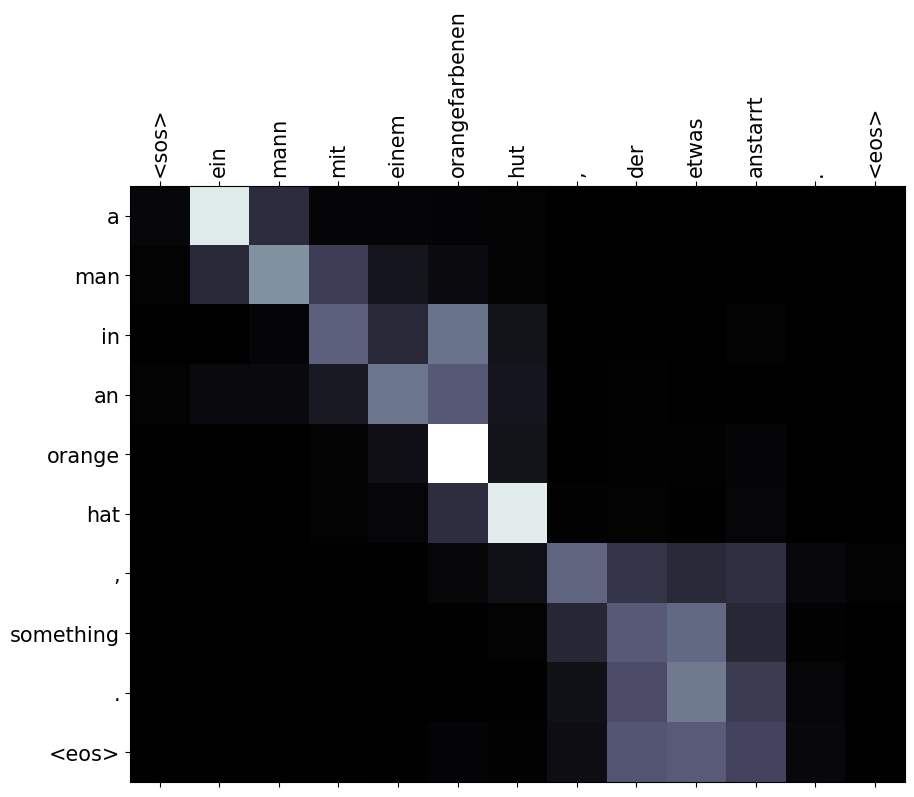

In [39]:
sentence = test_data[0]["de"]
expected_translation = test_data[0]["en"]

translation, sentence_tokens, attention = translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

print("Source:", sentence)
print("Expected:", expected_translation)
print("Predicted:", translation)

plot_attention(
    sentence_tokens,
    translation,
    attention,
)